# notebook 04 - task 2.1 & 2.2: text-based label prediction

**assignment requirement:** use cluster labels from part 1 as ground truth for a
supervised text classification task. predict which effort group a pr belongs to
using the pr description.

**task 2.1 (20%):** describe and justify text representation and classification pipeline.
**task 2.2 (10%):** implement, evaluate with per-class precision/recall/f1,
confusion matrix, acknowledging class imbalance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

import sys
sys.path.append("..")
from src.config.settings import (
    FIG_DIR,
    CLUSTER_PALETTE,
    RANDOM_STATE,
    TEST_SIZE,
    TFIDF_MAX_FEATURES,
    TFIDF_NGRAM_RANGE,
    TFIDF_MIN_DF,
    TFIDF_MAX_DF,
    DATA_DIR,
)
from src.utils.helper import (
    load_clustered,
    prepare_text_data,
    preprocess_text,
    CLUSTER_LABEL_MAP,
)

FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

## 1. load clustered data and prepare text

In [2]:
df = load_clustered()
print(f"loaded: {len(df):,} rows")
print(f"cluster distribution:")
for c in sorted(df["cluster"].unique()):
    n = (df["cluster"] == c).sum()
    print(f"  cluster {c} ({CLUSTER_LABEL_MAP[c]}): {n:,} ({100*n/len(df):.1f}%)")

loaded: 22,559 rows
cluster distribution:
  cluster 0 (intensively reviewed): 1,292 (5.7%)
  cluster 1 (auto-merged small): 8,187 (36.3%)
  cluster 2 (cursorily reviewed): 2,974 (13.2%)
  cluster 3 (auto-merged large): 10,106 (44.8%)


In [3]:
df_text = prepare_text_data(df)
print(f"prs with non-empty body: {len(df_text):,} / {len(df):,} ({100*len(df_text)/len(df):.1f}%)")
print(f"\ncluster distribution after text filter:")
for c in sorted(df_text["cluster"].unique()):
    n = (df_text["cluster"] == c).sum()
    print(f"  cluster {c} ({CLUSTER_LABEL_MAP[c]}): {n:,} ({100*n/len(df_text):.1f}%)")

prs with non-empty body: 22,411 / 22,559 (99.3%)

cluster distribution after text filter:
  cluster 0 (intensively reviewed): 1,284 (5.7%)
  cluster 1 (auto-merged small): 8,149 (36.4%)
  cluster 2 (cursorily reviewed): 2,944 (13.1%)
  cluster 3 (auto-merged large): 10,034 (44.8%)


In [4]:
df_text["body_clean"] = preprocess_text(df_text["body"])
print("example cleaned bodies:")
for c in sorted(df_text["cluster"].unique()):
    example = df_text[df_text["cluster"] == c]["body_clean"].iloc[0][:150]
    print(f"\n  cluster {c} ({CLUSTER_LABEL_MAP[c]}):")
    print(f"    {example}")

example cleaned bodies:

  cluster 0 (intensively reviewed):
    details summary x1f6e0 devtools x1f6e0 summary p open in github codespaces install mlflow from this pr for databricks use the following command p deta

  cluster 1 (auto-merged small):
    summary fixes critical module resolution error on agents page that was causing complete page failure bug details fixes 1029 removed unused import from

  cluster 2 (cursorily reviewed):
    summary implements comprehensive build staleness detection to prevent claude code from using outdated cli binaries after source changes the system pro

  cluster 3 (auto-merged large):
    背景 現在 本プロジェクトにおいて以下のパス構成の不整合が生じています commands内のファイルでは絶対パス が使用されている 実際のプロジェクト構成では相対パス での参照が適切 ディレクトリ名についても と が混在している状況 これらの不整合により コマンドの実行時にファイルパスが正しく解決さ


## 2. text representation justification (task 2.1)

### text source: pr descriptions

pr descriptions (`body` column) contain the author's explanation of what the
pr does and why. we expect the following linguistic/topical signals to correlate
with effort clusters:

- **auto-merged small (cluster 1):** short descriptions, fix/docs keywords,
  version bump patterns, dependency update boilerplate.
- **auto-merged large (cluster 3):** feature descriptions, implementation
  details, long technical explanations. feat-related vocabulary.
- **cursorily reviewed (cluster 2):** moderate-length descriptions with
  fix/refactor keywords, some technical explanation.
- **intensively reviewed (cluster 0):** complex feature descriptions,
  architectural terms, breaking change mentions, migration notes.

### preprocessing decisions

- lowercase everything (pr descriptions mix cases inconsistently)
- strip code blocks (```...```) - code snippets are not topical signals
- strip urls (auto-generated links from bots like dependabot)
- collapse markdown formatting (headers, bold, links)
- remove punctuation, collapse whitespace

### classification methodology: tf-idf + logistic regression

**tf-idf vectorization:**
- unigrams + bigrams (ngram_range = (1, 2)) - bigrams capture phrases like
  "breaking change" or "fix bug" that unigrams miss
- max_features = 5,000 - controls dimensionality; enough for discrimination
  without overfitting on 22k samples
- min_df = 3 - removes rare terms (typos, project-specific jargon)
- max_df = 0.95 - removes corpus-wide stop words that tf-idf alone may not downweight

**logistic regression (multinomial):**
- well-suited for sparse, high-dimensional tf-idf features
- provides interpretable coefficients (which terms predict which cluster)
- class_weight='balanced' to handle the severe imbalance (5.7% to 44.8%)
- we also compare with linear svc as a strong baseline for text classification

## 3. train/test split (task 2.2)

we use stratified 80/20 split to preserve the class imbalance ratio in both
sets. this is critical because the smallest class (cluster 0) is only 5.7%
of the data - random splitting could produce a test set with near-zero
cluster 0 samples.

In [5]:
X = df_text["body_clean"].to_numpy().astype(str)
y = df_text["cluster"].to_numpy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"train: {len(X_train):,}  test: {len(X_test):,}")
print(f"\ntrain class distribution:")
for c in sorted(np.unique(y_train)):
    n = (y_train == c).sum()
    print(f"  cluster {c} ({CLUSTER_LABEL_MAP[c]}): {n:,} ({100*n/len(y_train):.1f}%)")
print(f"\ntest class distribution:")
for c in sorted(np.unique(y_test)):
    n = (y_test == c).sum()
    print(f"  cluster {c} ({CLUSTER_LABEL_MAP[c]}): {n:,} ({100*n/len(y_test):.1f}%)")

train: 17,928  test: 4,483

train class distribution:
  cluster 0 (intensively reviewed): 1,027 (5.7%)
  cluster 1 (auto-merged small): 6,519 (36.4%)
  cluster 2 (cursorily reviewed): 2,355 (13.1%)
  cluster 3 (auto-merged large): 8,027 (44.8%)

test class distribution:
  cluster 0 (intensively reviewed): 257 (5.7%)
  cluster 1 (auto-merged small): 1,630 (36.4%)
  cluster 2 (cursorily reviewed): 589 (13.1%)
  cluster 3 (auto-merged large): 2,007 (44.8%)


## 4. tf-idf vectorization

In [6]:
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"tf-idf matrix: {X_train_tfidf.shape}")
print(f"sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.3f}")

vocabulary size: 5,000
tf-idf matrix: (17928, 5000)
sparsity: 0.990


## 5. model training: logistic regression vs linear svc

In [8]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
lr.fit(X_train_tfidf, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_tfidf))
lr_f1 = f1_score(y_test, lr.predict(X_test_tfidf), average="macro")
print(f"logistic regression: accuracy={lr_acc:.3f}, macro-f1={lr_f1:.3f}")


logistic regression: accuracy=0.672, macro-f1=0.596


In [9]:
svc = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=5000,
)
svc.fit(X_train_tfidf, y_train)
svc_acc = accuracy_score(y_test, svc.predict(X_test_tfidf))
svc_f1 = f1_score(y_test, svc.predict(X_test_tfidf), average="macro")

print(f"linear svc:           accuracy={svc_acc:.3f}, macro-f1={svc_f1:.3f}")

linear svc:           accuracy=0.665, macro-f1=0.575


## 6. detailed evaluation (logistic regression)

confusion matrix: tf-idf + logistic regression

In [10]:
y_pred = lr.predict(X_test_tfidf)

target_names = [f"{c}: {CLUSTER_LABEL_MAP[c]}" for c in sorted(np.unique(y_test))]
print(classification_report(y_test, y_pred, target_names=target_names))

                         precision    recall  f1-score   support

0: intensively reviewed       0.34      0.58      0.43       257
   1: auto-merged small       0.71      0.70      0.71      1630
  2: cursorily reviewed       0.45      0.55      0.50       589
   3: auto-merged large       0.81      0.69      0.75      2007

               accuracy                           0.67      4483
              macro avg       0.58      0.63      0.60      4483
           weighted avg       0.70      0.67      0.68      4483



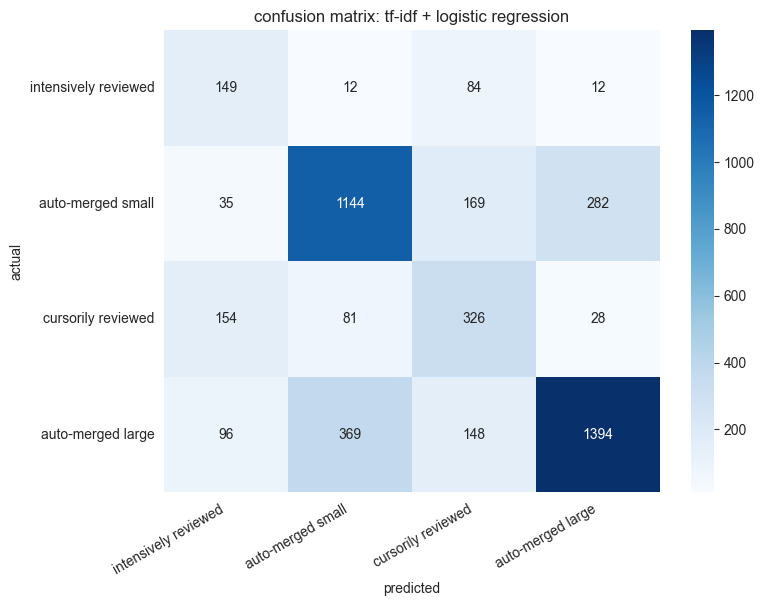

In [11]:
cm = confusion_matrix(y_test, y_pred)
labels = [CLUSTER_LABEL_MAP[c] for c in sorted(np.unique(y_test))]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("confusion matrix: tf-idf + logistic regression")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
fig.savefig(FIG_DIR / "04_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

normalized confusion matrix (row-normalized: of all actual cluster x, what % was predicted as y):

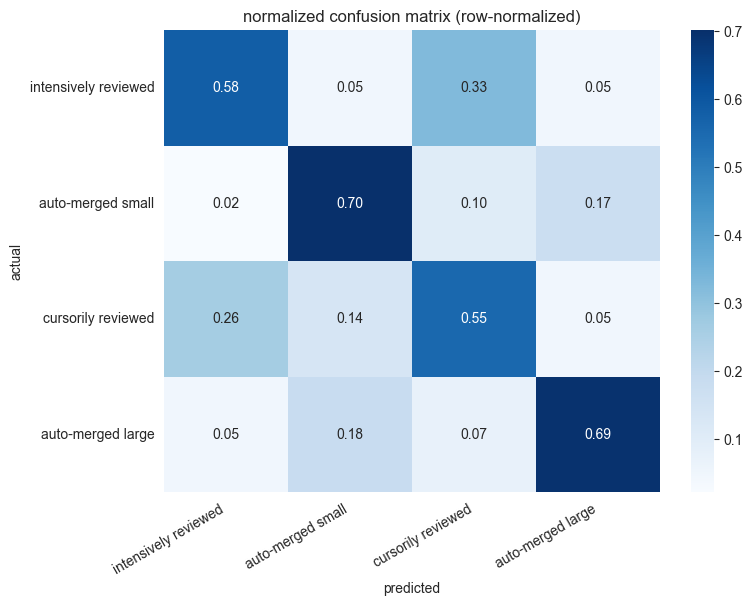

In [12]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("normalized confusion matrix (row-normalized)")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
fig.savefig(FIG_DIR / "04_confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. class imbalance discussion

the four clusters are heavily imbalanced:
- cluster 0 (intensively reviewed): ~5.7% of data
- cluster 1 (auto-merged small): ~36.3%
- cluster 2 (cursorily reviewed): ~13.2%
- cluster 3 (auto-merged large): ~44.8%

**accuracy alone is insufficient** because a naive classifier that always
predicts cluster 3 (the majority class) would achieve ~44.8% accuracy
without learning anything. we therefore report:
- **macro-averaged f1:** treats each class equally regardless of size
- **per-class precision, recall, f1:** shows performance on each cluster
- **confusion matrix:** reveals specific misclassification patterns

we use `class_weight='balanced'` in logistic regression to upweight minority
classes during training, ensuring the model does not ignore cluster 0.

## 8. top discriminating terms per cluster

In [13]:
feature_names = np.array(tfidf.get_feature_names_out())


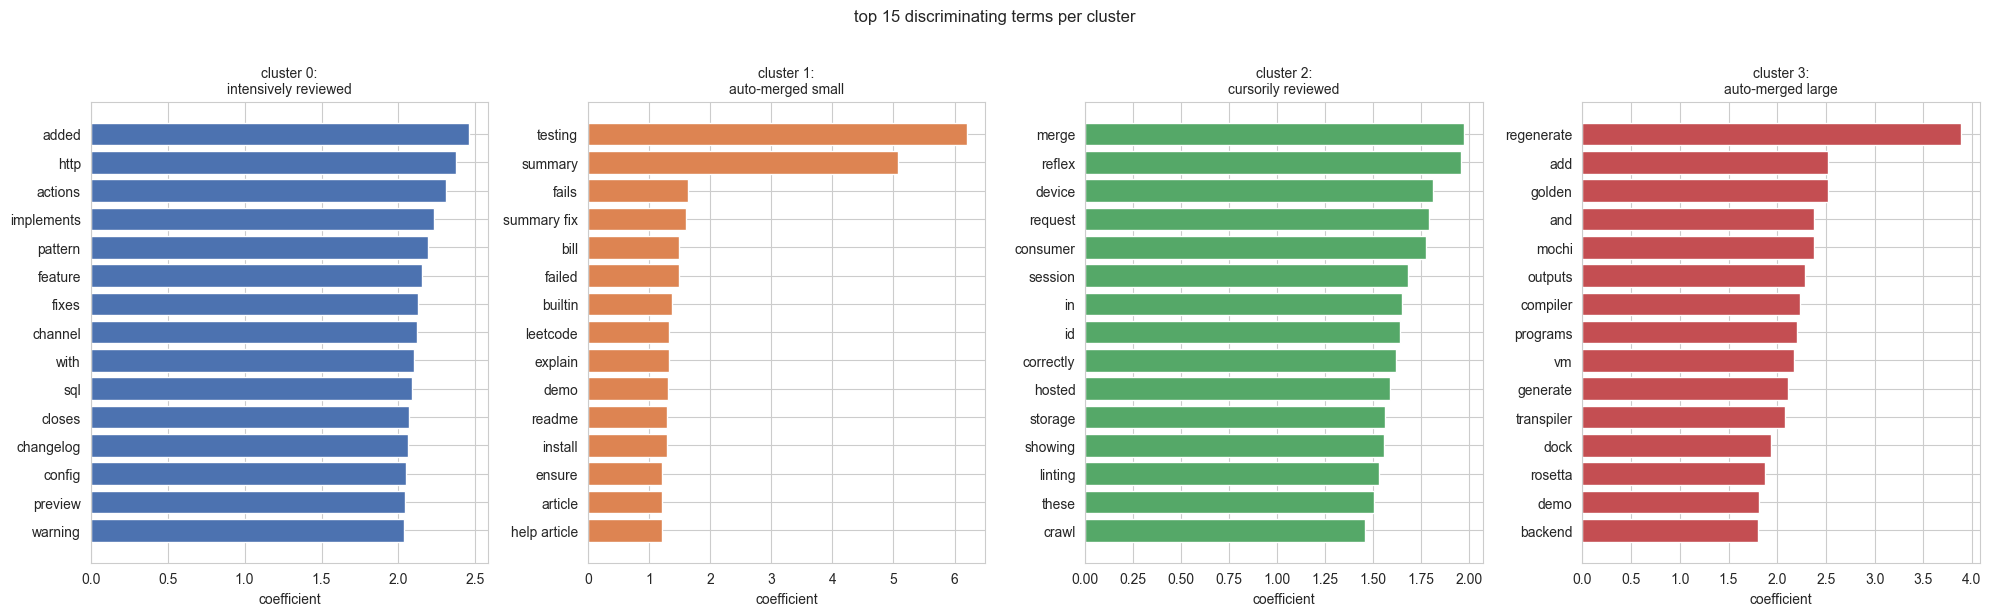

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for c in range(4):
    coefs = lr.coef_[c]
    top_idx = np.argsort(coefs)[-15:]
    top_terms = feature_names[top_idx]
    top_vals = coefs[top_idx]
    ax = axes[c]
    ax.barh(top_terms, top_vals, color=CLUSTER_PALETTE[str(c)])
    ax.set_title(f"cluster {c}:\n{CLUSTER_LABEL_MAP[c]}", fontsize=10)
    ax.set_xlabel("coefficient")

fig.suptitle("top 15 discriminating terms per cluster", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_top_terms_per_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

top 10 discriminating terms per cluster:

In [15]:
for c in range(4):
    coefs = lr.coef_[c]
    top_idx = np.argsort(coefs)[-10:]
    top_terms = feature_names[top_idx]
    print(f"\n  cluster {c} ({CLUSTER_LABEL_MAP[c]}):")
    for t, v in zip(reversed(top_terms), reversed(coefs[top_idx])):
        print(f"    {t:25s} {v:.3f}")


  cluster 0 (intensively reviewed):
    added                     2.460
    http                      2.371
    actions                   2.307
    implements                2.232
    pattern                   2.191
    feature                   2.153
    fixes                     2.128
    channel                   2.122
    with                      2.100
    sql                       2.090

  cluster 1 (auto-merged small):
    testing                   6.194
    summary                   5.069
    fails                     1.643
    summary fix               1.606
    bill                      1.489
    failed                    1.488
    builtin                   1.383
    leetcode                  1.332
    explain                   1.320
    demo                      1.311

  cluster 2 (cursorily reviewed):
    merge                     1.971
    reflex                    1.956
    device                    1.809
    request                   1.791
    consumer                  

## 9. save predictions

In [16]:
results_df = pd.DataFrame({
    "body_clean": X_test,
    "cluster_true": y_test,
    "cluster_pred_lr": y_pred,
    "cluster_pred_svc": svc.predict(X_test_tfidf),
})
results_df["cluster_label_true"] = results_df["cluster_true"].map(CLUSTER_LABEL_MAP)
results_df["cluster_label_pred_lr"] = results_df["cluster_pred_lr"].map(CLUSTER_LABEL_MAP)

In [17]:
results_df.to_parquet(DATA_DIR / "classification_results.parquet", index=False)
print(f"saved {len(results_df):,} test predictions to classification_results.parquet")

saved 4,483 test predictions to classification_results.parquet
